# System Configuration and Performance Profiling

To evaluate the performance and energy efficiency of HPC workloads on the smshost cluster, a comprehensive system profiling report was generated using a custom Bash script (system.pny). This report captures information spanning hardware, software, memory topology, energy monitoring, and job scheduling configuration. The detailed system overview enables informed analysis of parallelization parameters, energy efficiency, and potential bottlenecks for computational workloads such as LAMMPS and OpenFOAM.

## 1. Host and Operating System

The host node is identified using:

In [ ]:
hostname
date
cat /etc/os-release
uptime

The report shows that smshost runs Rocky Linux 8.10, a stable RHEL-compatible OS. Uptime and load averages are captured to indicate system idleness, which is important before benchmarking.






    
## 2. CPU Architecture and Frequency

CPU information is collected via:

lscpu
cat /proc/cpuinfo | grep "MHz"


The system has dual Intel Xeon E5-2680 CPUs, 16 cores total, 1 thread per core, and 2 NUMA nodes. Per-core frequencies are captured to observe CPU scaling and turbo boost behavior. This informs decisions about MPI process count and OpenMP thread allocation.

## 3. Memory Configuration

Memory usage is reported using:


In [ ]:
free -h
dmidecode -t memory




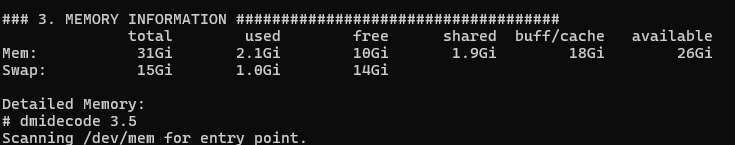


The node has 31 GiB RAM and 15 GiB swap, distributed across NUMA nodes. NUMA-awareness is critical for memory-bound HPC applications, and dmidecode provides detailed hardware information, such as memory module sizes and speeds.

## .4 GPU and Accelerator Resources

In [ ]:
if command -v nvidia-smi &> /dev/null; then nvidia-smi -q; else echo "No NVIDIA GPU detected"; fi


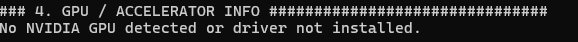

No GPU or accelerator was found, meaning all workloads rely on CPU cores. This emphasizes the importance of CPU parallelization, NUMA placement, and memory optimization.

## 5 Network and Interconnects

Network information is captured with:

In [ ]:
ip a
lspci | grep -i net


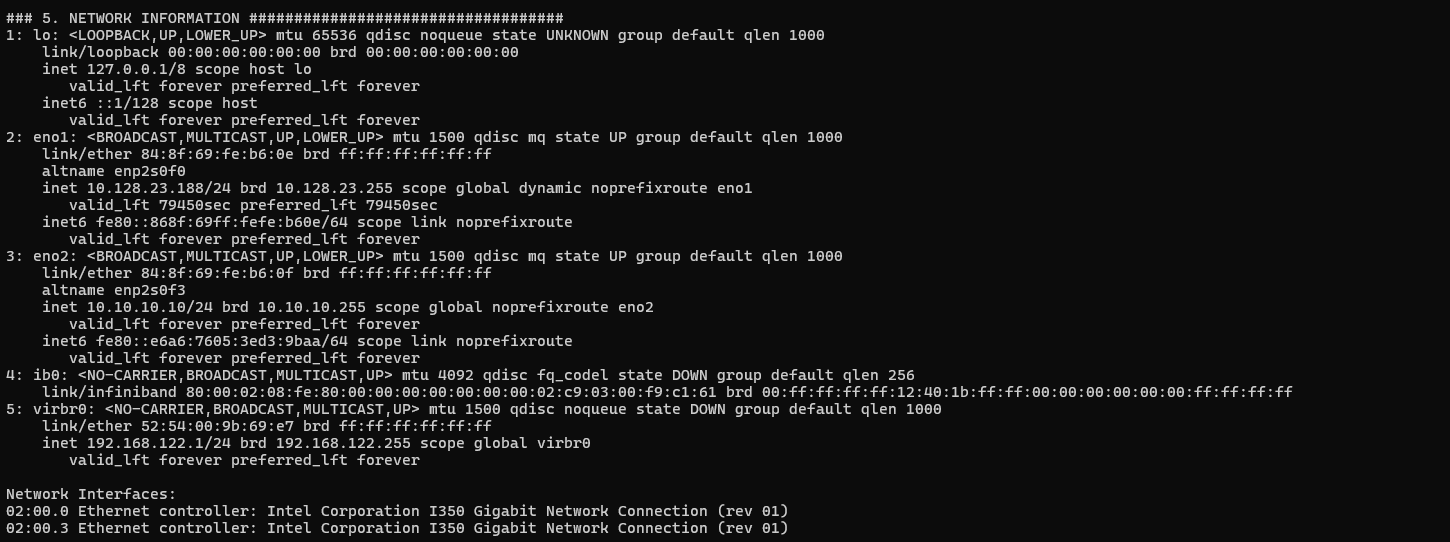

The system includes Intel Ethernet and Mellanox InfiniBand interfaces. These commands provide IP addresses, link status, and PCI device information, which are essential for distributed MPI workloads requiring high-speed, low-latency communication.

## 6 Storage Configuration

Storage is reported via:

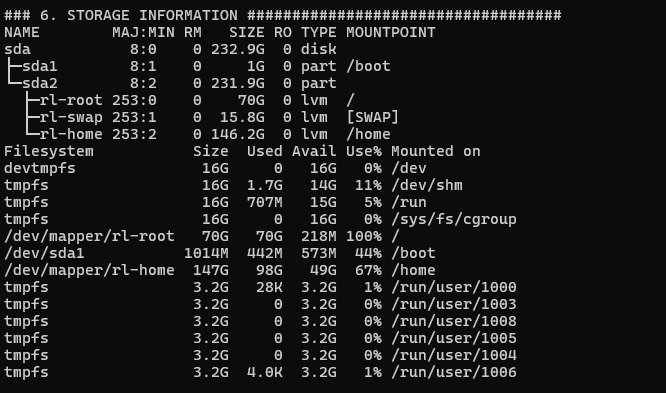

A single 232.9 GB disk is partitioned into root, swap, and home. Root is nearly full while home has significant free space. Storage availability is key for simulation checkpointing and temporary data storage

## 7. Power Monitoring

Energy consumption is measured using Intel RAPL:

In [ ]:
ls /sys/class/powercap/
for zone in /sys/class/powercap/intel-rapl:*; do cat $zone/energy_uj; done


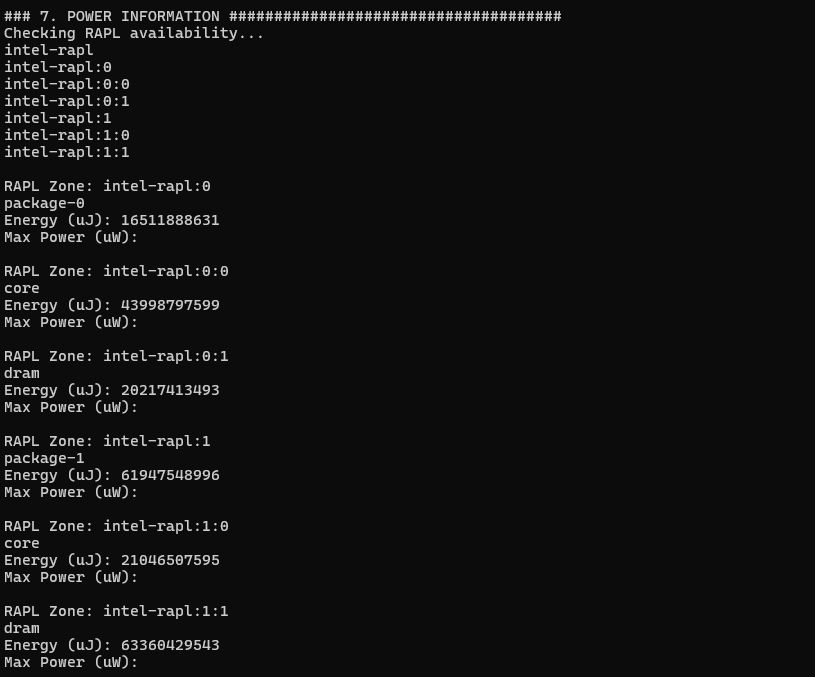

Package-level, core, and DRAM energy readings are recorded in microjoules (µJ), enabling calculation of energy efficiency metrics like timestep per watt in LAMMPS simulations.

## 8. Job Scheduling and Parallelization Environment

SLURM configuration and node states are captured with:

In [ ]:
sinfo -Nel
squeue
scontrol show config


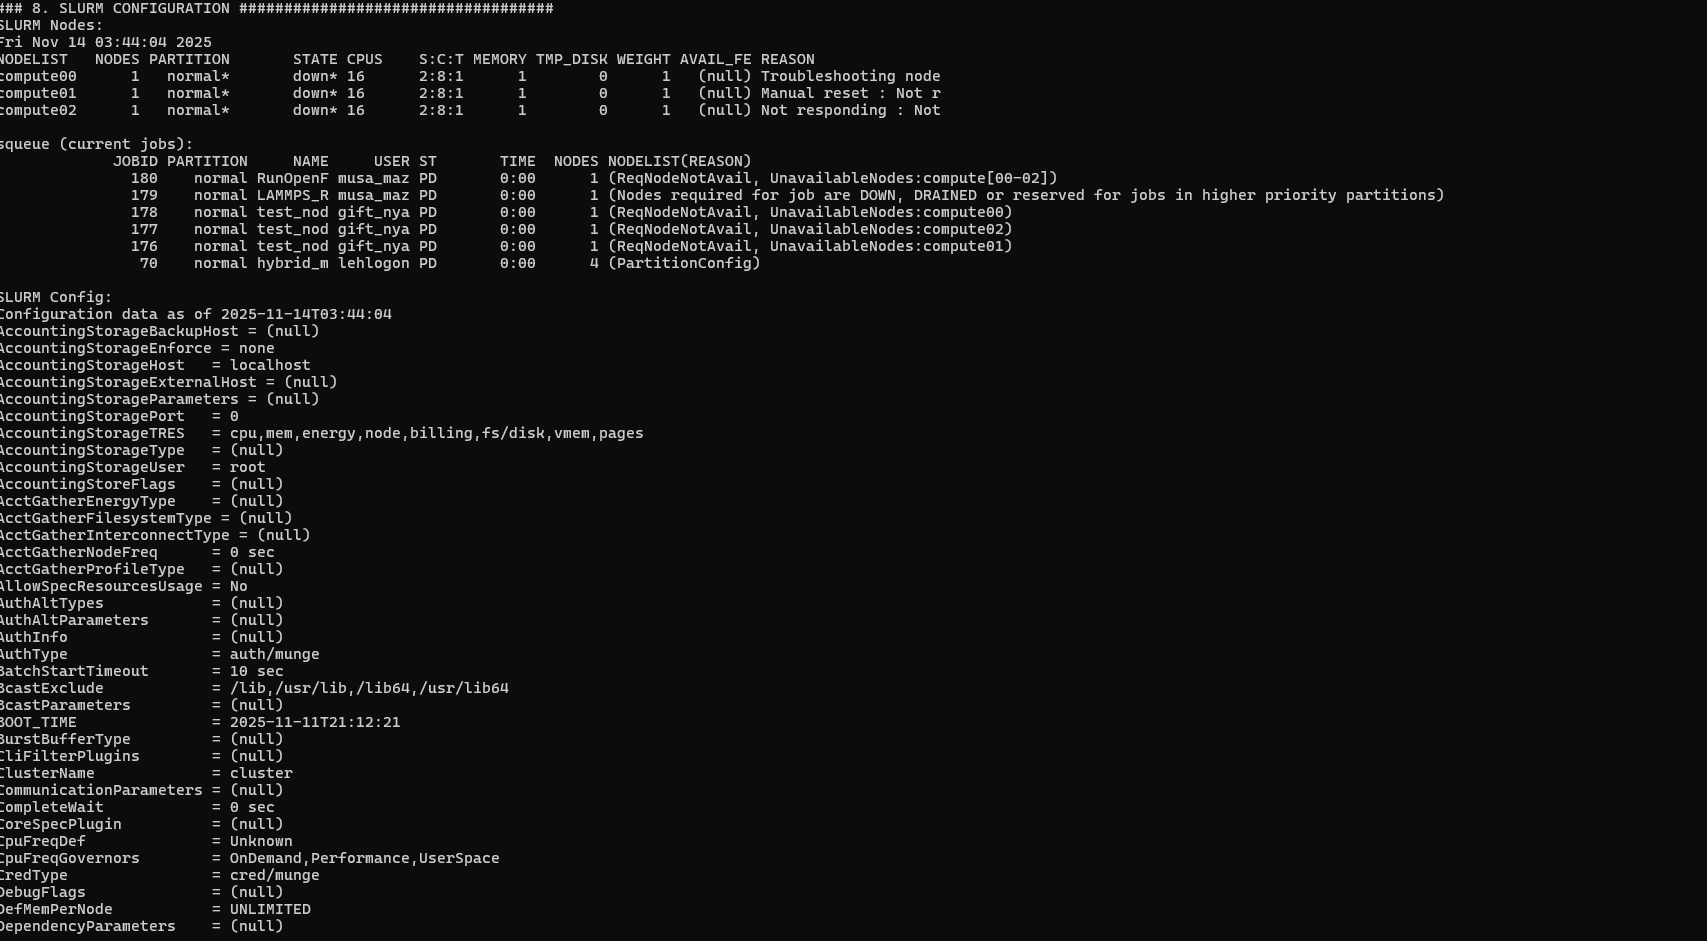

This shows node availability, partitions, job queues, and scheduling policies. Understanding SLURM’s CPU binding and cgroup constraints is critical for optimizing MPI/OpenMP parallel workloads.

## 9. Modules and Software Stack

The software stack is enumerated via:

In [ ]:
module avail
which mpirun
mpirun --version
gcc --version
g++ --version
gfortran --version


Multiple compilers and MPI libraries are available (OpenMPI 4.1.6, GCC 12.4), along with scientific libraries (PETSc, Hypre, FFTW). This ensures reproducibility and the ability to optimize simulations using different parallelization strategies.

## 10. NUMA and Topology

NUMA layout is captured with:

In [ ]:
lstopo --output-format txt


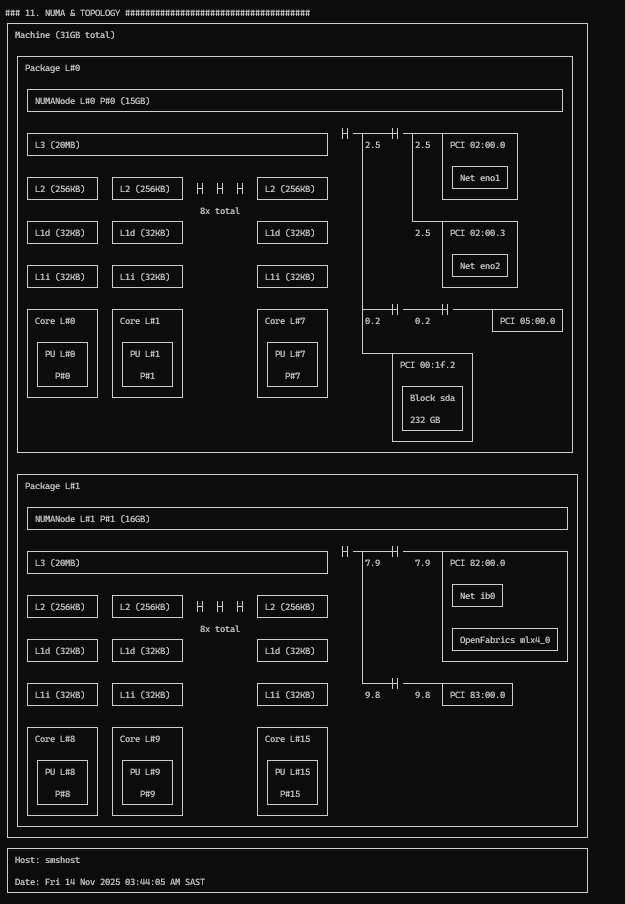